# Data Manipulation with pandas

## Topics covered:

1. Transforming DataFrames
2. Aggregating DataFrame
3. Slicing and Indexing DataFrames
4. Creating and Visualizing DataFrame
5. Handling missing values
6. Reshaping data

This Notebook contains arguments and methods to manipulate dataframes.

- DataFrames: A two-dimensional labeled data structure in pandas, sumular to a spreadsheet or SQL table, that holds rows and columns of data.
- Series: A one-dimensional array-like pandas object that contains data for a single variables, with an index to label each value.
- Index: The labels or row identifiers of a pandas Series or DataFrame that allow for easy data alignment and selection.
- Mask: A pandas Series of Boolean values (True/False) used to filter rows of a DataFrame.
- Boolean Indexing: Selecting rows or columns in a DataFrame using logical conditions that return True or False.
- _loc[]_: A pandas method used to select rows and columns by label or conditional statements.
- _iloc[]_: A pandas method used to select rows and columns by integer position.
- Slicing: Extracting a subset of rows or columns from a DataFrame or Series using index ranges.
- Aggregation: The process of summarizing data values, such as calculating the sum, mean, or count.
- GroupBy: A pandas method to splot data into groups based on one or more variables and aggregated across multiple dimensions.
- _apply()_: A pandas function that applies a given function along an axis of a DataFrame, often slower than built-in methods.
- Imputation: The process of handling missing values by replacing them with substituted values such as mean, median, or placeholder.
- _fillna()_: A pandas methods used to replace missing values with specific values.
- _dropna()_: A pandas methods used to remove rows or columns with missing values.
- *set_index()*: A method to assign one or more columns as the index of a DataFrame.
- *reset_index()*: A method to restore the default integer index of a DataFrame, moving any existing index back into columns.
- *sort_values()*: A method to sort a DataFrame by one or more column values.
- *sort_index()*: A method to sort a DataFrame by its index values.
- *describe()*: A method to generate summary statistics (mean, median, count, etc.) for numerical columns in a DataFrame.
- _head()_: A method taht displays the first five rows of a DataFrame by default.
- _info()_: A method to print concise details about a DataFrame, including column data types and non-null values.
- *read_csv()*: A pandas function to import data from a CSV file into a DataFrame.
- *to_csv()*: A pandas function to export a DataFrame to a CSV file.

## 1. DataFrames

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (5,3)

In [237]:
df = pd.read_csv("../ZDatasets/homelessness.csv", index_col=0)
df.head()

,region,state,individuals,family_members,state_pop
0,East South Central,Alabama,2570.0,864.0,4887681
1,Pacific,Alaska,1434.0,582.0,735139
2,Mountain,Arizona,7259.0,2606.0,7158024
3,West South Central,Arkansas,2280.0,432.0,3009733
4,Pacific,California,109008.0,20964.0,39461588


In [238]:
### Exploring a DataFrame
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   region          51 non-null     object 
 1   state           51 non-null     object 
 2   individuals     51 non-null     float64
 3   family_members  51 non-null     float64
 4   state_pop       51 non-null     int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 2.4+ KB
None
(51, 5)
         individuals  family_members     state_pop
count      51.000000       51.000000  5.100000e+01
mean     7225.784314     3504.882353  6.405637e+06
std     15991.025083     7805.411811  7.327258e+06
min       434.000000       75.000000  5.776010e+05
25%      1446.500000      592.000000  1.777414e+06
50%      3082.000000     1482.000000  4.461153e+06
75%      6781.500000     3196.000000  7.340946e+06
max    109008.000000    52070.000000  3.946159e+07


In [239]:
### Components of a Dataframe
df.values
print(df.columns)
print(df.index)

Index(['region', 'state', 'individuals', 'family_members', 'state_pop'], dtype='object')
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50],
      dtype='int64')


### 1.2. Sorting the DataFrame

#### 1.2.1 Sort a column in descending order

In [240]:
df.sort_values('state', ascending=False).head()

,region,state,individuals,family_members,state_pop
50,Mountain,Wyoming,434.0,205.0,577601
49,East North Central,Wisconsin,2740.0,2167.0,5807406
48,South Atlantic,West Virginia,1021.0,222.0,1804291
47,Pacific,Washington,16424.0,5880.0,7523869
46,South Atlantic,Virginia,3928.0,2047.0,8501286


#### 1.2.2 Sort by multiple variables

In [241]:
df.sort_values(['region','state'],ascending=[False,True]).head()

,region,state,individuals,family_members,state_pop
3,West South Central,Arkansas,2280.0,432.0,3009733
18,West South Central,Louisiana,2540.0,519.0,4659690
36,West South Central,Oklahoma,2823.0,1048.0,3940235
43,West South Central,Texas,19199.0,6111.0,28628666
15,West North Central,Iowa,1711.0,1038.0,3148618


#### 1.2.3 Subsetting

In [242]:
# Subsetting columns
df['state'].head()

0       Alabama
1        Alaska
2       Arizona
3      Arkansas
4    California
Name: state, dtype: object

In [243]:
# Subsetting multiple columns
df[['region','state']].head()

# Or
subset_col = ['region','state']
df[subset_col].head()

,region,state
0,East South Central,Alabama
1,Pacific,Alaska
2,Mountain,Arizona
3,West South Central,Arkansas
4,Pacific,California


In [244]:
# Subsetting rows
df[df['family_members'] < 500].head()

,region,state,individuals,family_members,state_pop
3,West South Central,Arkansas,2280.0,432.0,3009733
7,South Atlantic,Delaware,708.0,374.0,965479
24,East South Central,Mississippi,1024.0,328.0,2981020
26,Mountain,Montana,983.0,422.0,1060665
28,Mountain,Nevada,7058.0,486.0,3027341


In [245]:
# Subsetting based on text
df[df['state'] == "Arkansas"]

,region,state,individuals,family_members,state_pop
3,West South Central,Arkansas,2280.0,432.0,3009733


In [246]:
# Subsetting based on multiple conditions
under_400_fm = df['family_members'] < 400
region_mountain = df['region'] == "Mountain"
df[under_400_fm & region_mountain]

,region,state,individuals,family_members,state_pop
50,Mountain,Wyoming,434.0,205.0,577601


In [247]:
# Using .isin()
condition = df['state'].isin(['Wyoming'])
df[condition]

,region,state,individuals,family_members,state_pop
50,Mountain,Wyoming,434.0,205.0,577601


## 2. Summary statistics

In [248]:
# Summarising numerical data
df.head()
print(f"Mean: {df['family_members'].mean()}")
print(f"Median: {df['family_members'].median()}")
print(f"Mode: {df['family_members'].mode()}")
print(f"Var: {df['family_members'].var()}")
print(f"Std: {df['family_members'].std()}")
print(f"Sum: {df['family_members'].sum()}")
print(f"Quantile 0.75: {df['family_members'].quantile(0.75)}")
print(f"Min: {df['family_members'].min()}")
print(f"Max: {df['family_members'].max()}")

Mean: 3504.8823529411766
Median: 1482.0
Mode: 0    3250.0
Name: family_members, dtype: float64
Var: 60924453.54588234
Std: 7805.411811421761
Sum: 178749.0
Quantile 0.75: 3196.0
Min: 75.0
Max: 52070.0


### 2.1 Summaries on multiple columns

In [249]:
df[['family_members','individuals']].agg(["mean", "median", "var", "std"])

,family_members,individuals
mean,3.504882e+03,7.225784e+03
median,1.482000e+03,3.082000e+03
var,6.092445e+07,2.557129e+08
std,7.805412e+03,1.599103e+04


### 2.2 Dropping duplicates

In [250]:
# Drop duplicated values
df.drop_duplicates(subset="individuals").head()

,region,state,individuals,family_members,state_pop
0,East South Central,Alabama,2570.0,864.0,4887681
1,Pacific,Alaska,1434.0,582.0,735139
2,Mountain,Arizona,7259.0,2606.0,7158024
3,West South Central,Arkansas,2280.0,432.0,3009733
4,Pacific,California,109008.0,20964.0,39461588


### 2.3 Inspect categorical columns

In [251]:
# Each region count in descending order
df['region'].value_counts(sort=True).head()

region
South Atlantic        9
Mountain              8
West North Central    7
New England           6
Pacific               5
Name: count, dtype: int64

In [252]:
# Proportions
df['region'].value_counts(normalize=True).head()

region
South Atlantic        0.176471
Mountain              0.156863
West North Central    0.137255
New England           0.117647
Pacific               0.098039
Name: proportion, dtype: float64

In [253]:
# New dataframe
Bicycle = pd.read_csv("../ZDatasets/Bicycle.csv", index_col=0)
Bicycle.head()

/var/folders/bh/_p1bkhtn09b6syd7vz5f61pw0000gn/T/ipykernel_14335/3210569861.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  Bicycle = pd.read_csv("../ZDatasets/Bicycle.csv", index_col=0)


,NB_TRAFFIC_SURVEY,NB_LOCATION_TRAFFIC_SURVEY,Sort Des,DS_LOCATION,DT_ANALYSIS_SUMMARY,NB_YEAR,NB_MONTH,NB_WEEKDAY_NONHOL_QTR,CT_VOLUME_AMPEAK,CT_VOLUME_PMPEAK,...,CT_VOLUME_24HOUR,DS_HOLIDAY,NB_SEASONALITY_PERIOD,NB_TYPE_PERIOD,Primary,weekend,Quarter,Season,Cyclying Season,day
Unique_ID,,,,,,,,,,,,,,,,,,,,,
1,9305,3,St Georges St Hawthorn,(BIKE PATH)ST. GEORGES ST 2WAY 50M S OF HAWTHO...,09/06/2007,2007,6,0,39,46,...,480,NaN,11,3,False,True,2,Winter,Non-Cycling,Sat
2,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,17/03/2008,2008,3,41,62,82,...,654,NaN,6,1,False,False,1,Autumn,Cycling,Mon
3,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,19/03/2008,2008,3,41,59,117,...,794,NaN,6,1,False,False,1,Autumn,Cycling,Wed
4,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,20/03/2008,2008,3,0,59,80,...,732,EASTHU,7,3,False,False,1,Autumn,Cycling,Thu
5,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,21/03/2008,2008,3,0,18,24,...,221,EASTER,7,3,False,False,1,Autumn,Cycling,Fri


### 2.4 Pivot tables

In [254]:
Bicycle.pivot_table(values="CT_VOLUME_PMPEAK", index = "Season", columns = "day",aggfunc = "median", margins=True)

day,Fri,Mon,Sat,Sun,Thu,Tue,Wed,All
Season,,,,,,,,
Autumn,86.0,109.0,50.0,56.0,108.0,121.0,118.0,83.0
Spring,79.0,112.0,45.0,53.0,105.5,111.0,115.0,80.0
Summer,72.0,102.0,43.0,48.0,99.0,110.0,101.0,72.0
Winter,66.0,85.0,41.0,45.0,81.0,90.0,86.0,63.0
All,75.0,100.0,44.0,50.0,98.0,107.0,103.0,74.0


## 3. Explicit indexes

### 3.1 Setting a column as the index

In [255]:
# Set and remove an index
Bicycle.set_index("NB_TRAFFIC_SURVEY")
Bicycle.reset_index(drop = True).head() # If you want to drop it as well

,NB_TRAFFIC_SURVEY,NB_LOCATION_TRAFFIC_SURVEY,Sort Des,DS_LOCATION,DT_ANALYSIS_SUMMARY,NB_YEAR,NB_MONTH,NB_WEEKDAY_NONHOL_QTR,CT_VOLUME_AMPEAK,CT_VOLUME_PMPEAK,...,CT_VOLUME_24HOUR,DS_HOLIDAY,NB_SEASONALITY_PERIOD,NB_TYPE_PERIOD,Primary,weekend,Quarter,Season,Cyclying Season,day
0,9305,3,St Georges St Hawthorn,(BIKE PATH)ST. GEORGES ST 2WAY 50M S OF HAWTHO...,09/06/2007,2007,6,0,39,46,...,480,NaN,11,3,False,True,2,Winter,Non-Cycling,Sat
1,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,17/03/2008,2008,3,41,62,82,...,654,NaN,6,1,False,False,1,Autumn,Cycling,Mon
2,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,19/03/2008,2008,3,41,59,117,...,794,NaN,6,1,False,False,1,Autumn,Cycling,Wed
3,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,20/03/2008,2008,3,0,59,80,...,732,EASTHU,7,3,False,False,1,Autumn,Cycling,Thu
4,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,21/03/2008,2008,3,0,18,24,...,221,EASTER,7,3,False,False,1,Autumn,Cycling,Fri


## 4. Visualising data

<Axes: >

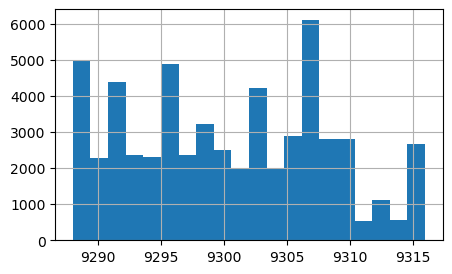

In [256]:
# Histogram
Bicycle['NB_TRAFFIC_SURVEY'].hist(bins=20)

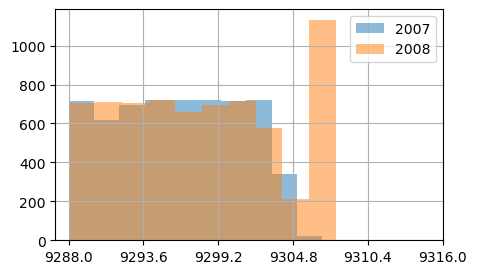

In [257]:
# Transparent Barplot
Bicycle[Bicycle['NB_YEAR'] == 2007]['NB_TRAFFIC_SURVEY'].hist(alpha = 0.5)
Bicycle[Bicycle['NB_YEAR'] == 2008]['NB_TRAFFIC_SURVEY'].hist(alpha = 0.5)
plt.legend([2007,2008])
plt.xticks(np.linspace(min(Bicycle["NB_TRAFFIC_SURVEY"]), max(Bicycle["NB_TRAFFIC_SURVEY"]), 6))
plt.show()

## 5. Missing data
- Affects distributions
- Less representative of the population
- Can result in drawing incorrect conclusions

### 5.1 Detecting missing values

In [258]:
# Quick overview
first_five_columns = Bicycle.isna().sum().sort_values(ascending=False).head()
first_five_columns

DS_HOLIDAY                    41566
Primary                         631
NB_TRAFFIC_SURVEY                 0
NB_LOCATION_TRAFFIC_SURVEY        0
Cyclying Season                   0
dtype: int64

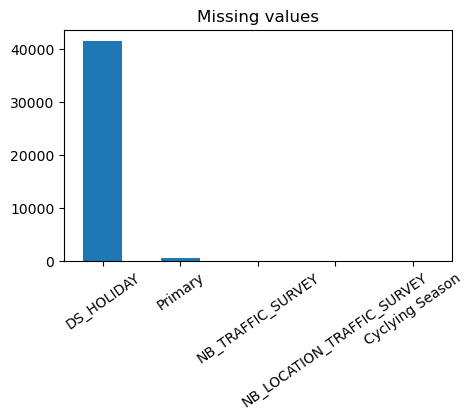

In [259]:
# Plot missing data
first_five_columns.plot(kind="bar", rot=35, title="Missing values")
plt.show()

In [260]:
# Drop missing values
Bicycle.dropna()
# Replace missing values
Bicycle.fillna(0).head()

,NB_TRAFFIC_SURVEY,NB_LOCATION_TRAFFIC_SURVEY,Sort Des,DS_LOCATION,DT_ANALYSIS_SUMMARY,NB_YEAR,NB_MONTH,NB_WEEKDAY_NONHOL_QTR,CT_VOLUME_AMPEAK,CT_VOLUME_PMPEAK,...,CT_VOLUME_24HOUR,DS_HOLIDAY,NB_SEASONALITY_PERIOD,NB_TYPE_PERIOD,Primary,weekend,Quarter,Season,Cyclying Season,day
Unique_ID,,,,,,,,,,,,,,,,,,,,,
1,9305,3,St Georges St Hawthorn,(BIKE PATH)ST. GEORGES ST 2WAY 50M S OF HAWTHO...,09/06/2007,2007,6,0,39,46,...,480,0,11,3,False,True,2,Winter,Non-Cycling,Sat
2,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,17/03/2008,2008,3,41,62,82,...,654,0,6,1,False,False,1,Autumn,Cycling,Mon
3,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,19/03/2008,2008,3,41,59,117,...,794,0,6,1,False,False,1,Autumn,Cycling,Wed
4,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,20/03/2008,2008,3,0,59,80,...,732,EASTHU,7,3,False,False,1,Autumn,Cycling,Thu
5,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,21/03/2008,2008,3,0,18,24,...,221,EASTER,7,3,False,False,1,Autumn,Cycling,Fri


### 5.2 Strategies for addressing missing data
- Drop missing values (5% or less of total values)
- Impute mean, median, mode (Depends on distribution and context)
- Impute by sub-group (E.g. Different experience levels have different median salary)

#### 5.2.1 Dropping missing values

In [261]:
# Define a threshold
threshold = len(Bicycle) * 0.05
# Drop missing values
cols_to_drop = Bicycle.columns[Bicycle.isna().sum() >= threshold]
Bicycle.dropna(subset=cols_to_drop).head() # "inplace = True" will keep amend the dataset

,NB_TRAFFIC_SURVEY,NB_LOCATION_TRAFFIC_SURVEY,Sort Des,DS_LOCATION,DT_ANALYSIS_SUMMARY,NB_YEAR,NB_MONTH,NB_WEEKDAY_NONHOL_QTR,CT_VOLUME_AMPEAK,CT_VOLUME_PMPEAK,...,CT_VOLUME_24HOUR,DS_HOLIDAY,NB_SEASONALITY_PERIOD,NB_TYPE_PERIOD,Primary,weekend,Quarter,Season,Cyclying Season,day
Unique_ID,,,,,,,,,,,,,,,,,,,,,
4,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,20/03/2008,2008,3,0,59,80,...,732,EASTHU,7,3,False,False,1,Autumn,Cycling,Thu
5,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,21/03/2008,2008,3,0,18,24,...,221,EASTER,7,3,False,False,1,Autumn,Cycling,Fri
6,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,22/03/2008,2008,3,0,19,28,...,271,EASTER,7,3,False,True,1,Autumn,Cycling,Sat
7,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,23/03/2008,2008,3,0,11,33,...,272,EASTER,7,3,False,True,1,Autumn,Cycling,Sun
8,9306,1,Flemington Rd NW Bound Lane,(BIKE LANE)FLEMINGTON RD NW BD 10M SE OF DRYBU...,24/03/2008,2008,3,0,16,27,...,227,EASTER,7,3,False,False,1,Autumn,Cycling,Mon


#### 5.2.2 Imputing a summary statistic
The below will impute all missing values of "cols_with_missing_values" with the columns mode.

In [262]:
cols_with_missing_values = Bicycle.columns[Bicycle.isna().sum() > 0]
for col in cols_with_missing_values[:-1]:
    Bicycle[col].fillna(Bicycle[col].mode()[0])

#### 5.2.3 Imputing by sub-group
Missing values will be imputed by the columns median per subgroup.

In [263]:
na_dict = Bicycle.groupby('NB_YEAR')['CT_VOLUME_12HOUR'].median().to_dict()
Bicycle['CT_VOLUME_12HOUR'] = Bicycle['CT_VOLUME_12HOUR'].fillna(Bicycle['NB_YEAR'].map(na_dict))

## 6. Reshaping Data

### 6.1 Reshaping data with _.melt()_
- melt method ise used to unpivot datasets

In [264]:
# Create a synthetic dataset
social_fin = pd.DataFrame({
    'financial': ['total_revenue', 'gross_profit', 'net_income', 'total_revenue', 'gross_profit', 'net_income'],
    'company': ['twitter', 'twitter', 'twitter', 'facebook', 'facebook', 'facebook'],
    2018: [3042359, 2077362, 1205596, 55838000, 46483000, 22112000],
    2017: [2443299, 1582057,  905596, 49838000, 39583000, 20112000],
    2016: [2154399, 1420057,  705596, 44210000, 36520000, 18102000],
    2015: [1891200, 1245057,  605596, 39230000, 32510000, 16100000],
    2014: [1600000, 1100000,  505000, 34200000, 29000000, 14000000]
})
social_fin.head()

,financial,company,2018,2017,2016,2015,2014
0,total_revenue,twitter,3042359,2443299,2154399,1891200,1600000
1,gross_profit,twitter,2077362,1582057,1420057,1245057,1100000
2,net_income,twitter,1205596,905596,705596,605596,505000
3,total_revenue,facebook,55838000,49838000,44210000,39230000,34200000
4,gross_profit,facebook,46483000,39583000,36520000,32510000,29000000


In [265]:
# Melt transformation
social_fin_tall = social_fin.melt(
    id_vars=['financial', 'company'],
    value_vars=[2018,2017,2016,2015,2014],
    var_name='year',
    value_name='dollars')
social_fin_tall.head()

,financial,company,year,dollars
0,total_revenue,twitter,2018,3042359
1,gross_profit,twitter,2018,2077362
2,net_income,twitter,2018,1205596
3,total_revenue,facebook,2018,55838000
4,gross_profit,facebook,2018,46483000


## 7. Datetime
- *pd.to_datetime()* coverts arguments to DateTime data

In [ ]:
# Get the data
divorce = pd.read_csv("../ZDatasets/divorce.csv", parse_dates = ['marriage_date'])
divorce.dtypes

divorce_date                 object
dob_man                      object
education_man                object
income_man                  float64
dob_woman                    object
education_woman              object
income_woman                float64
marriage_date        datetime64[ns]
marriage_duration           float64
num_kids                    float64
dtype: object

### 7.1 Creating DateTime data
Below function can extract parts of a datetime object:
- *.dt.year* -> year
- *.dt.month* -> month
- *.dt.day* -> day

In [ ]:
# Create a new month column
divorce['month'] = divorce['marriage_date'].dt.month
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
divorce['month'] = divorce['month'].map(month_map)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
divorce['month'] = pd.Categorical(divorce['month'], categories = month_order, ordered = True)
divorce.head()

,divorce_date,dob_man,education_man,income_man,dob_woman,education_woman,income_woman,marriage_date,marriage_duration,num_kids,month
0,2006-09-06,1975-12-18,Secondary,2000.0,1983-08-01,Secondary,1800.0,2000-06-26,5.0,1.0,Jun
1,2008-01-02,1976-11-17,Professional,6000.0,1977-03-13,Professional,6000.0,2001-09-02,7.0,NaN,Sep
2,2011-01-02,1969-04-06,Preparatory,5000.0,1970-02-16,Professional,5000.0,2000-02-02,2.0,2.0,Feb
3,2011-01-02,1979-11-13,Secondary,12000.0,1981-05-13,Secondary,12000.0,2006-05-13,2.0,NaN,May
4,2011-01-02,1982-09-20,Professional,6000.0,1988-01-30,Professional,10000.0,2007-08-06,3.0,NaN,Aug


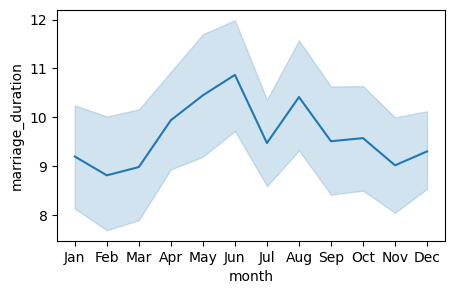

In [ ]:
# Lineplot is perfect to show trends
sns.lineplot(data = divorce, x="month", y = 'marriage_duration')
plt.show()